In [1]:
import os
import sys
from copy import deepcopy
from time import sleep, time
import pygame
import random
from pygame.locals import QUIT, KEYDOWN
from multiprocessing import Pool, Process
import json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

import torch
from torch import nn
import torch.nn.functional as F
# -*- coding:utf-8 -*-

pygame 2.5.2 (SDL 2.28.3, Python 3.10.14)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [2]:
GRID_WIDTH = 22
GRID_HEIGHT = 26
SHOW_GHOST = True
START_POS_BIAS = 2
LEFT_EDGE_LEN = 6
RIGHT_EDGE_LEN = 6
UP_EDGE_LEN = 3
DOWN_EDGE_LEN = 3

device = torch.device('cuda:0')
#device = torch.device('cpu')

In [3]:
S = [[[0, 0, 0, 0], [0, 2, 2, 0], [2, 2, 0, 0], [0, 0, 0, 0]],
     [[0, 0, 0, 0], [2, 0, 0, 0], [2, 2, 0, 0], [0, 2, 0, 0]],
     [[0, 0, 0, 0], [0, 0, 0, 0], [0, 2, 2, 0], [2, 2, 0, 0]],
     [[0, 0, 0, 0], [0, 2, 0, 0], [0, 2, 2, 0], [0, 0, 2, 0]],
    ]
Z = [[[0, 0, 0, 0], [3, 3, 0, 0], [0, 3, 3, 0], [0, 0, 0, 0]],
     [[0, 0, 0, 0], [0, 0, 3, 0], [0, 3, 3, 0], [0, 3, 0, 0]],
     [[0, 0, 0, 0], [0, 0, 0, 0], [3, 3, 0, 0], [0, 3, 3, 0]],
     [[0, 0, 0, 0], [0, 3, 0, 0], [3, 3, 0, 0], [3, 0, 0, 0]],
    ]
T = [[[0, 0, 0, 0], [0, 4, 0, 0], [4, 4, 4, 0], [0, 0, 0, 0]],
     [[0, 0, 0, 0], [0, 4, 0, 0], [0, 4, 4, 0], [0, 4, 0, 0]],
     [[0, 0, 0, 0], [0, 0, 0, 0], [4, 4, 4, 0], [0, 4, 0, 0]],
     [[0, 0, 0, 0], [0, 4, 0, 0], [4, 4, 0, 0], [0, 4, 0, 0]],
    ]
L = [[[0, 0, 0, 0], [0, 0, 5, 0], [5, 5, 5, 0], [0, 0, 0, 0]],
     [[0, 0, 0, 0], [0, 5, 0, 0], [0, 5, 0, 0], [0, 5, 5, 0]],
     [[0, 0, 0, 0], [0, 0, 0, 0], [5, 5, 5, 0], [5, 0, 0, 0]],
     [[0, 0, 0, 0], [5, 5, 0, 0], [0, 5, 0, 0], [0, 5, 0, 0]],
    ]
J = [[[0, 0, 0, 0], [6, 0, 0, 0], [6, 6, 6, 0], [0, 0, 0, 0]],
     [[0, 0, 0, 0], [0, 6, 6, 0], [0, 6, 0, 0], [0, 6, 0, 0]],
     [[0, 0, 0, 0], [0, 0, 0, 0], [6, 6, 6, 0], [0, 0, 6, 0]],
     [[0, 0, 0, 0], [0, 6, 0, 0], [0, 6, 0, 0], [6, 6, 0, 0]],
    ]
I = [[[0, 0, 0, 0], [7, 7, 7, 7], [0, 0, 0, 0], [0, 0, 0, 0]],
     [[0, 0, 7, 0], [0, 0, 7, 0], [0, 0, 7, 0], [0, 0, 7, 0]],
     [[0, 0, 0, 0], [0, 0, 0, 0], [7, 7, 7, 7], [0, 0, 0, 0]],
     [[0, 7, 0, 0], [0, 7, 0, 0], [0, 7, 0, 0], [0, 7, 0, 0]],
    ]
O = [[[0, 0, 0, 0], [0, 8, 8, 0], [0, 8, 8, 0], [0, 0, 0, 0]],
     [[0, 0, 0, 0], [0, 8, 8, 0], [0, 8, 8, 0], [0, 0, 0, 0]],
     [[0, 0, 0, 0], [0, 8, 8, 0], [0, 8, 8, 0], [0, 0, 0, 0]],
     [[0, 0, 0, 0], [0, 8, 8, 0], [0, 8, 8, 0], [0, 0, 0, 0]],
    ]

In [4]:
tetris_serial = {
    0:S,
    1:Z,
    2:T,
    3:L,
    4:J,
    5:I,
    6:O,
}

In [5]:
#RGB
BASE = (191, 191, 191)
BLACK = (15, 15, 63)
S_COLOR = (0,255,0)
Z_COLOR = (255,0,0)
T_COLOR = (255,0,255)
L_COLOR = (255,102,0)
J_COLOR = (0,0,255)
I_COLOR = (0,255,255)
O_COLOR = (255,255,0)
WHITE = (255, 255, 255)

In [6]:
color_key = {
    0:BASE,
    1:BLACK,
    2:S_COLOR,
    3:Z_COLOR,
    4:T_COLOR,
    5:L_COLOR,
    6:J_COLOR,
    7:I_COLOR,
    8:O_COLOR
}

In [7]:
tetris_list = [0, 1, 2, 3, 4, 5, 6]

In [8]:
combo_score = {
    0: 0,
    1: 0,
    2: 1,
    3: 1,
    4: 1,
    5: 2,
    6: 2,
    7: 3,
    8: 3,
    9: 4,
    10: 4,
    11: 4
}

In [9]:
class TETRIS:
    def __init__(self):
        self.hold_tetris = 0
        self.state = 0
        self.edge = [int(GRID_WIDTH / 2) - START_POS_BIAS, 2] #upleft, (x, y)
        self.ground_wait = [0, 0, 0]
        
        self.touchGround = False
        self.next_block = False
        self.isHold = False
        self.isTurnHold = False
        self.spined = False
        
        self.gameover = False
        
        self.tetris_queue = random.sample(tetris_list, 7)
        self.next5 = [self.tetris_queue.pop(0) for i in range(5)]
        self.now_tetris = self.tetris_queue.pop(0)
        
    def __getitem__(self):
        return (tetris_serial.get(self.now_tetris)[self.state], self.edge)
    
    def __gettetr__(self):
        return self.now_tetris
    
    def __getstate__(self):
        return self.state
    
    def __getedge__(self):
        return self.edge
    
    def __getholdtetr__(self):
        return self.hold_tetris
    
    def __getnext5__(self):
        return self.next5
    
    def __gethold__(self):
        return (tetris_serial.get(self.hold_tetris)[0], self.isHold)
    
    def __getnext__(self):
        return self.next5
    
    def __hasSpin__(self):
        return self.spined
    
    def __hasgameover__(self):
        return self.gameover
    
    def __hasturnhold__(self):
        return self.isTurnHold
    
    def time4next(self):
        return self.next_block
    
    def get_next_piece(self, plate):
        self.now_tetris = self.next5.pop(0)
        if not self.tetris_queue:
            self.tetris_queue = random.sample(tetris_list, 7)
        self.next5.append(self.tetris_queue.pop(0))
        self.state = 0
        self.edge = [int(GRID_WIDTH / 2) - START_POS_BIAS, 2]
        self.ground_wait = [0, 0, 0]
        self.touchGround = False
        self.next_block = False
        self.isTurnHold = False
        self.spined = False
        
        if not self.isCollision(self.edge[0], self.edge[1], self.state, plate):
            self.gameover = True
    
    def update(self, key, plate):
        if key == pygame.K_UP or key == pygame.K_x: #CLOCKWISE SPIN
            if self.isCollision(self.edge[0], self.edge[1], (self.state + 1) % 4, plate):
                self.state = (self.state + 1) % 4
                self.spined = True
                if self.isLegal(self.edge[0], self.edge[1] + 1, self.state, plate):
                    self.touchGround = True
        elif key == pygame.K_z: #COUNTERCLOCKWISE SPIN
            if self.isCollision(self.edge[0], self.edge[1], (self.state - 1) % 4, plate):
                self.state = (self.state - 1) % 4
                self.spined = True
                if self.isLegal(self.edge[0], self.edge[1] + 1, self.state, plate):
                    self.touchGround = True
        elif key == pygame.K_a: #180 SPIN
            if self.isCollision(self.edge[0], self.edge[1], (self.state + 2) % 4, plate):
                self.state = (self.state + 2) % 4
                self.spined = True
        elif key == pygame.K_RIGHT: #MOVE RIGHT
            if self.isLegal(self.edge[0] + 1, self.edge[1], self.state, plate):
                self.edge[0] += 1
                self.spined = False
        elif key == pygame.K_LEFT: #MOVE LEFT
            if self.isLegal(self.edge[0] - 1, self.edge[1], self.state, plate):
                self.edge[0] += -1
                self.spined = False
        elif key == pygame.K_RETURN: #FALL DOWN BY TIME
            if self.isLegal(self.edge[0], self.edge[1] + 1, self.state, plate):
                self.edge[1] += 1
            else:
                if self.touchGround:
                    self.ground_wait.pop(0)
                    if not self.ground_wait:
                        self.next_block = True
                else:
                    self.spined = False
                    self.touchGround = True
        elif key == pygame.K_DOWN: #SOFT DROP
            if self.isLegal(self.edge[0], self.edge[1] + 1, self.state, plate):
                while self.isLegal(self.edge[0], self.edge[1] + 1, self.state, plate):
                    self.edge[1] += 1
            else:
                if self.touchGround:
                    self.ground_wait.pop(0)
                    if not self.ground_wait:
                        self.next_block = True
                else:
                    self.spined = False
                    self.touchGround = True
        elif key == pygame.K_SPACE: #HARD DROP
            while self.isLegal(self.edge[0], self.edge[1] + 1, self.state, plate):
                self.edge[1] += 1
                self.spined = False
            self.next_block = True
            self.touchGround = True
        elif key == pygame.K_c: #HOLD
            if not self.isTurnHold:
                if self.isHold:
                    self.now_tetris, self.hold_tetris = self.hold_tetris, self.now_tetris
                    self.state = 0
                    self.edge = [int(GRID_WIDTH / 2) - START_POS_BIAS, 2]
                    self.ground_wait = [0, 0, 0]
                    self.next_block = False
                    self.touchGround = False
                    self.isTurnHold = True
                    self.spined = False
                else:
                    self.isHold = True
                    self.hold_tetris = self.now_tetris
                    self.get_next_piece(plate)
                    self.isTurnHold = True
        
    def isLegal(self, x, y, state, plate): #判斷方塊是否可以旋轉或移動，如果不能旋轉，判斷是否存在碰撞
        #檢查是否有重疊
        curr_tetris = tetris_serial.get(self.now_tetris)[state]
        for i in range(4):
            for j in range(4):
                if curr_tetris[j][i] != 0 and plate[x + i][y + j] != 0:
                    return False
        return True
    
    def isCollision(self, x, y, state, plate):
        with Pool(10) as pool:
            if self.isLegal(x, y, state, plate):
                return True
            elif self.isLegal(x + 1, y + 1, state, plate):
                self.edge[0] += 1
                self.edge[1] += 1
                return True
            elif self.isLegal(x - 1, y + 1, state, plate):
                self.edge[0] += -1
                self.edge[1] += 1
                return True
            elif self.isLegal(x + 1, y, state, plate):
                self.edge[0] += 1
                return True
            elif self.isLegal(x - 1, y, state, plate):
                self.edge[0] += -1
                return True
            elif self.isLegal(x, y + 1, state, plate):
                self.edge[1] += 1
                return True
            elif self.isLegal(x, y - 1, state, plate):
                self.edge[1] += -1
                return True
            elif self.isLegal(x, y + 2, state, plate) and self.now_tetris == 2: #TST
                self.edge[1] += -2
                return True
            elif self.isLegal(x - 2, y, state, plate):# and self.now_tetris == 5:#I spin
                self.edge[0] += -2
                return True
            elif self.isLegal(x + 2, y, state, plate):# and self.now_tetris == 5: #I spin
                self.edge[0] += 2
                return True
            pool.close()
            pool.join()
        self.spined = False
        return False

In [10]:
class DASHBOARD:
    def __init__(self):
        self.score = 0
        self.b2b = 0
        self.tss = 0 #t-spin single
        self.tsd = 0 #t-spin double
        self.tst = 0 #t-spin triple
        self.tetris = 0
        self.triple = 0
        self.double = 0
        self.single = 0
        self.combo = -1
        self.fc = 0
        self.MAX_combo = 0
        self.MAX_b2b = 0
        self.total_placed = 0
        self.total_lines = 0
        
        self.isB2B = False
        self.isCombo = False
        self.isTspin = False
        
        self.level = 1
    
    def __getstastics__(self):
        return {'score':self.score,
                'tss':self.tss,
                'tsd':self.tsd,
                'tst':self.tst,
                'tetris':self.tetris,
                'triple':self.triple,
                'double':self.double,
                'single':self.single,
                'fc':self.fc,
                'max_combo':self.MAX_combo,
                'max_b2b':self.MAX_b2b}
    
    def __getscore__(self):
        return self.score
    
    def __getb2b__(self):
        return self.b2b
    
    def __getcombo__(self):
        return self.combo
    
    def __gettspin__(self):
        return self.isTSpin
    
    def __getplaced__(self):
        return self.total_placed
    
    def __getlines__(self):
        return self.total_lines
    
    def update(self, lines:int, tspin:bool, fc:bool):
        self.total_placed += 1
        self.total_lines = lines
        if lines == 0:
            self.reset_combo()
            return
        
        if tspin:
            self.isTSpin = True
            if lines == 1:
                self.tss += 1
                self.combo += 1
                self.b2b += 1
                self.compute_score(2)
            elif lines == 2:
                self.tsd += 1
                self.combo += 1
                self.b2b += 1
                self.compute_score(4)
            elif lines == 3:
                self.tst += 1
                self.combo += 1
                self.b2b += 1
                self.compute_score(6)
        else:
            self.isTSpin = False
            if lines == 1:
                self.single += 1
                self.combo += 1
                self.reset_b2b()
                self.compute_score(0)
            elif lines == 2:
                self.double += 1
                self.combo += 1
                self.reset_b2b()
                self.compute_score(1)
            elif lines == 3:
                self.triple += 1
                self.combo += 1
                self.reset_b2b()
                self.compute_score(2)
            elif lines == 4:
                self.tetris += 1
                self.combo += 1
                self.b2b += 1
                self.compute_score(4)
            if fc:
                self.fc += 1
                self.score += 10
    
    def compute_score(self, score:int):
        try:
            combo_addi = combo_score.get(self.combo)
        except:
            combo_addi = 5
        b2b_addi = 1.5 if (self.b2b > 1) else 1
            
        turn_score = combo_addi + int(b2b_addi * score)
        self.score += turn_score
        
    def reset_combo(self):
        if self.MAX_combo < self.combo:
            self.MAX_combo = self.combo
        self.combo = -1
    
    def reset_b2b(self):
        if self.MAX_b2b < self.b2b:
            self.MAX_b2b = self.b2b
        self.b2b = 0

In [11]:
#畫出盤面
def draw_tetris(bg, ground, tetris):
    draw_plate = deepcopy(ground)
    curr_tetris, (x, y) = tetris.__getitem__()
    
    #with Pool(1) as pool: #多執行緒執行
    #不畫出方塊以外的空格
    for i in range(4):
        for j in range(4):
            if curr_tetris[j][i]:# not draw_plate[x + i][j + y]:
                draw_plate[x + i][j + y] = curr_tetris[j][i]

    #draw hold tetris
    hold_tetris, hold = tetris.__gethold__()
    if hold:
        for i in range(4):
            for j in range(4):
                if hold_tetris[j][i]:
                    draw_plate[1 + i][1 + j] = hold_tetris[j][i]
    #draw next piece            
    next5 = tetris.__getnext__()
    piece_pos = 2
    for piece in next5:
        next_piece = tetris_serial.get(piece)[0]
        for i in range(4):
            for j in range(4):
                if next_piece[j][i]:
                    draw_plate[17 + i][piece_pos + j] = next_piece[j][i]
        piece_pos += 3

    #draw game plate
    for i in range(GRID_HEIGHT):
        for j in range(GRID_WIDTH):
            pygame.draw.rect(bg, color_key.get(draw_plate[j][i]), [j * 30, i * 30, 30, 30], 0)
        #pool.close()
        #pool.join()

In [12]:
def draw_dashboard(dashboard, window):
    score = dashboard.__getscore__()
    b2b = dashboard.__getb2b__()
    combo = dashboard.__getcombo__()
    
    ft = pygame.font.SysFont(name = None, size = 48)
    score_text = ft.render(f'{score:>10}', True, WHITE)
    score_meta = ft.render('Score: ', True, WHITE)
    
    if b2b >= 1:
        b2b_text = ft.render(f'b2b x {b2b:>2} !', True, WHITE)
        window.blit(b2b_text, (30, 30 * (UP_EDGE_LEN + 14)))
    if combo >= 1:
        combo_text = ft.render(f'{combo:>2} combo !', True, WHITE)
        window.blit(combo_text, (0, 30 * (UP_EDGE_LEN + 11)))
        
    window.blit(score_text, (60, 30 * (UP_EDGE_LEN + 19)))
    window.blit(score_meta, (60, 30 * (UP_EDGE_LEN + 17)))

In [13]:
def draw_timer(time, window):
    ft = pygame.font.SysFont(name = None, size = 48)
    time_text = ft.render(f'{int(time / 60)}:{int(time % 60):>2}', True, WHITE)
    window.blit(time_text, (60, 30 * (UP_EDGE_LEN + 8)))

In [14]:
# #when tetris touch the ground
def update_game_plate(game_plate, tetris)->int:
    curr_tetris, (x, y) = tetris.__getitem__()
    
    for i in range(4):
        for j in range(4):
            if curr_tetris[j][i]:# not draw_plate[x + i][j + y]:
                game_plate[x + i][j + y] = curr_tetris[j][i]
            
    eliminate_lines = 0
    all_clear = True
    t_spin = False
    #t-spin check
    if tetris.__gettetr__() == 2 and tetris.__hasSpin__():
        edge_count = 0
        edge_count += 1 if (game_plate[x][y + 1] != 0) else 0
        edge_count += 1 if (game_plate[x][y + 3] != 0) else 0
        edge_count += 1 if (game_plate[x + 2][y + 1] != 0) else 0
        edge_count += 1 if (game_plate[x + 2][y + 3] != 0) else 0
        if edge_count >= 3:
            t_spin = True
    for i in range(20):
        full = True
        for j in range(10):
            if game_plate[LEFT_EDGE_LEN + j][UP_EDGE_LEN + i] == 0:
                full = False
                break
        if full:
            eliminate_lines += 1
            for j in range(10):
                game_plate[LEFT_EDGE_LEN + j][UP_EDGE_LEN + i] = 0
                game_plate[LEFT_EDGE_LEN + j][UP_EDGE_LEN : UP_EDGE_LEN + 1 + i] = [0] + game_plate[LEFT_EDGE_LEN + j][UP_EDGE_LEN : UP_EDGE_LEN + i]
    
    if eliminate_lines:
        #all clear check
        for i in range(20):
            for j in range(10):
                if game_plate[LEFT_EDGE_LEN + j][UP_EDGE_LEN + i] != 0:
                    all_clear = False
                    break
            if not all_clear:
                break
    else:
        all_clear = False
                
    return eliminate_lines, all_clear, t_spin

In [15]:
def display_gameover(window):
    ft = pygame.font.SysFont(name = None, size = 96)
    game = ft.render('{:^}'.format('GAME'), True, WHITE, BLACK)
    over = ft.render('{:^}'.format('OVER'), True, WHITE, BLACK)
    
    ft_hint = pygame.font.SysFont(name = None, size = 48)
    hint = ft_hint.render('{:^}'.format('press any key to leave'), True, WHITE, BLACK)
    
    window.blit(game, (GRID_WIDTH / 2 * 30 - 100, 120))
    window.blit(over, (GRID_WIDTH / 2 * 30 - 90, 180))
    window.blit(hint, (GRID_WIDTH / 2 * 30 - 175, 300))

In [16]:
valid_key = {
    pygame.K_DOWN,
    pygame.K_UP,
    pygame.K_LEFT,
    pygame.K_RIGHT,
    pygame.K_z,
    pygame.K_x,
    pygame.K_c,
    pygame.K_a,
    pygame.K_SPACE,
}

In [17]:
def play():
    myTetris = TETRIS()
    dashboard = DASHBOARD()
    pygame.init()

    GAME_PLATE = [[0 for j in range(GRID_HEIGHT)] for i in range(GRID_WIDTH)]
    for i in range(LEFT_EDGE_LEN):
        GAME_PLATE[i][:] = [1] * GRID_HEIGHT
    for i in range(RIGHT_EDGE_LEN):
        GAME_PLATE[GRID_WIDTH - 1 - i][:] = [1] * GRID_HEIGHT
    for i in range(GRID_WIDTH):
        for j in range(UP_EDGE_LEN):
            GAME_PLATE[i][j] = 1
        for j in range(DOWN_EDGE_LEN):
            GAME_PLATE[i][GRID_HEIGHT - 1 - j] = 1

    screen = pygame.display.set_mode((GRID_WIDTH * 30, GRID_HEIGHT * 30))
    screen.fill(BASE)
    pygame.display.set_caption("PYTRIS")
    pygame.display.update()

    background = pygame.Surface(screen.get_size())
    background = background.convert()
    background.fill(BASE)

    draw_tetris(background, GAME_PLATE, myTetris)

    UPDATE_PERIOD = 1
    update_timer = 0
    game_time = time()

    hourglass = 120

    while True:
        #隨時間下降
        update_timer += time() - game_time
        hourglass -= (time() - game_time)
        game_time = time()
        if update_timer > UPDATE_PERIOD:
            pygame.event.post(pygame.event.Event(KEYDOWN, {'key': pygame.K_DOWN}))
            update_timer = 0

        for event in pygame.event.get():
            if event.type == KEYDOWN:
                if event.key == pygame.K_ESCAPE:
                    pygame.quit()
                    sys.exit()
                if event.key in valid_key:
                    myTetris.update(event.key, GAME_PLATE)

            if event.type == QUIT:
                pygame.quit()
                sys.exit()
            draw_tetris(background, GAME_PLATE, myTetris)

            if myTetris.time4next():
                lines, fc, tspin = update_game_plate(GAME_PLATE, myTetris)
                dashboard.update(lines, tspin, fc)
                myTetris.get_next_piece(GAME_PLATE)

            screen.blit(background, (0, 0))
            draw_dashboard(dashboard, screen)
            draw_timer(hourglass, screen)
            pygame.display.update()

        if myTetris.__hasgameover__():
            display_gameover(screen)
            pygame.display.update()
            pygame.time.wait(1500) #ms
            pygame.event.clear()
            event = pygame.event.wait()
            while(pygame.event.wait().type != KEYDOWN):
                event = pygame.event.wait()

            stastics = dashboard.__getstastics__()
            for key, value in stastics.items():
                print(key, ':', value)

            pygame.quit()
            return stastics
            #sys.exit()

        if hourglass < 0:
            stastics = dashboard.__getstastics__()
            for key, value in stastics.items():
                print(key, ':', value)

            pygame.quit()
            return stastics
            #sys.exit()

## Agent Design

**States  S**: GAME_PLATE, TETRIS.now_tetris, TETRIS.state, TETRIS.edge, TETRIS.hold, TETRIS.isTurnHold, TETRIS.next5

**Action A**: spin clockwise, spin counterclockwise, spin 180, left, right, soft drop, hard drop, hold

**Reward R**: Score

In [18]:
#ACTIONS = 8
#STATES  = 211
ACTIONS = 40
STATES = 208

In [19]:
#old net
class net(nn.Module):
    def __init__(self, N_states, N_actions):
        super(net, self).__init__()
        self.linear1 = nn.Linear(N_states,512)
        self.linear2 = nn.Linear(512, 1024)
        self.linear3 = nn.Linear(1024, 512)
        self.out = nn.Linear(512, N_actions)
        
        self.dropout1 = nn.Dropout()
        self.dropout2 = nn.Dropout()
        self.dropout3 = nn.Dropout()
        
    def forward(self, x):
        x = F.relu(self.dropout1(self.linear1(x)))
        x = F.relu(self.dropout1(self.linear2(x)))
        x = F.relu(self.dropout1(self.linear3(x)))
        return self.out(x)

In [20]:
# #conv net
# class net(nn.Module):
#     def __init__(self, N_states, N_actions):
#         super(net, self).__init__()
#         self.linear1 = nn.Linear(N_states - 200, 64)
#         self.conv1 = nn.Conv2d(1,  4, 4, 1, 1)
#         self.conv2 = nn.Conv2d(4, 16, 3, 1, 0)
#         #self.linear2 = nn.Linear(10 * 20 * 4, 128)
#         self.linear2 = nn.Linear(7 * 17 * 16, 128)
#         self.linear3 = nn.Linear(128, 64)
        
#         self.out = nn.Linear(64, N_actions)
#         self.dropout1 = nn.Dropout()
        
#     def forward(self, x):
#         if x.dim() == 1:
#             x = x.view(-1, STATES)
#         plate = x[:, :200].view(-1, 1, 10, 20)
#         tetr  = x[:, 200:]
        
#         tetr = F.relu(self.linear1(tetr))
#         plate = self.conv1(plate)
#         plate = self.conv2(plate)
#         #plate = plate.view(-1, 10 * 20 * 4)
#         plate = plate.view(-1, 7 * 17 * 16)
#         plate = self.linear2(plate)
#         plate = self.linear3(plate)
#         return self.out(torch.add(plate, tetr))

In [21]:
class tetris_bot(nn.Module):
    def __init__(self, imitate = False, load = False, store = False):
        super(tetris_bot, self).__init__()
        self.epsilon = 1
        self.BATCH_SIZE = 32
        self.MEMORY_SIZE = 512
        self.counter = 0
        self.GAMMA = 0.9
        self.learn_count = 0
        self.imitate = imitate
        self.store = store
        
        self.eval_net = net(N_states = STATES, N_actions = ACTIONS)
        self.target_net = net(N_states = STATES, N_actions = ACTIONS)
        self.pro_net = net(N_states = STATES, N_actions = ACTIONS)
        self.memory = torch.zeros((self.MEMORY_SIZE, STATES * 2 + 2))
        self.avg_reward = []
        self.train_loss = []
        
        self.loss_func = nn.MSELoss()
        self.optimizer = torch.optim.Adam(self.eval_net.parameters(), lr = 1e-3)
        if load:
            #pro_dict = torch.load('pro_net.pth')
            #self.pro_net.load_state_dict(pro_dict)
            eval_dict = torch.load('eval_net.pth')
            target_dict = torch.load('target_net.pth')
            self.eval_net.load_state_dict(eval_dict)
            self.target_net.load_state_dict(target_dict)
        
    def store_transition(self, s, a, r, s_):
        r = torch.tensor([r], dtype = torch.float32).to(device)
        a = torch.tensor([a]).to(device)
        d = torch.cat((s, a, r, s_))
        if self.counter and (self.counter % self.MEMORY_SIZE == 0):
            self.learn()
        pos = self.counter % self.MEMORY_SIZE
        self.memory[pos, :] = d
        self.counter += 1
        
        
    def forward(self, s):
        if random.random() < self.epsilon:
            a = torch.rand(ACTIONS).to(device)
            return a
        else:
            return self.eval_net(s)
    
    def get_reward(self, s, a, _s, dashboard):
        heights = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
        holes = 0
        
        for i in range(10):
            filled = False
            for j in range(20):
                if _s[i + j * 10] != 0:
                    heights[i] = 20 - j
                    filled = True
                if filled and _s[i + j * 10] == 0:
                    holes += 1
        max_height = max(heights)
        mean_height = np.array(heights).mean()
        bumpiness = sum([np.absolute(h - mean_height) for h in heights])
        
        score = dashboard.__getscore__()
        lines_bonus = dashboard.__getlines__() * 10
        place_bonus = dashboard.__getplaced__() * 1
        height_penalty = -max_height * 0.5
        bumpiness_penalty = -bumpiness * 0.2
        holes_penalty = -holes * 0.2
        
        reward = 0
        reward += score 
        reward += lines_bonus
        reward += place_bonus
        reward += height_penalty 
        reward += bumpiness_penalty 
        reward += holes_penalty
#         print(lines_bonus)
#         print(place_bonus)
#         print(height_penalty)
#         print(bumpiness_penalty)
#         print(holes_penalty)
#         print('height:   ', total_height)
#         print('bumpiness:', bumpiness)
#         print('holes:    ', holes)
#         NORMALIZE_SCORE = 3
#         reward = reward + NORMALIZE_SCORE
        return reward
        
    def learn(self):
        if self.learn_count and self.learn_count % 10 == 0:
            self.target_net.load_state_dict(self.eval_net.state_dict())
            if self.imitate:
                self.pro_net.load_state_dict(self.eval_net.state_dict())
                torch.save(self.pro_net.state_dict(), 'pro_net.pth')
        
        sample = np.random.choice(self.MEMORY_SIZE, self.BATCH_SIZE) #從MEMORY_SIZE中挑BATCH_SIZE個數
        buffer = self.memory[sample, :]
        b_s = torch.tensor(buffer[:, :STATES], dtype = torch.float32).to(device)
        b_a = torch.tensor(buffer[:, STATES:STATES+1], dtype = torch.long).to(device)
        b_r = torch.tensor(buffer[:, STATES+1:STATES+2], dtype = torch.float32).to(device)
        b_s_= torch.tensor(buffer[:, -STATES:], dtype = torch.float32).to(device)
        
        q_eval = self.eval_net(b_s).gather(1, b_a)
        q_next = self.target_net(b_s_).detach() #預測未來哪個action會獲得最好的reward
        q_target = b_r + self.GAMMA * q_next.max(1)[0].view(self.BATCH_SIZE, 1) #回傳target_function中預測的最大reward
        loss = self.loss_func(q_eval, q_target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        self.learn_count += 1
        self.avg_reward.append(b_r.mean().item())
        self.train_loss.append(loss.item())
        self.plot_reward()
        #if self.learn_count and self.learn_count % 100 == 0:
        #    self.epsilon *= 0.8
        self.epsilon = max(self.epsilon * 0.995, 0.1)
        if self.store:
            self.store_model()
        
    def write_mem(self, fpath):
        json.dump(memory, fpath)
        
    def store_model(self):
        torch.save(self.pro_net.state_dict(), 'pro_net.pth')
        torch.save(self.eval_net.state_dict(), 'eval_net.pth')
        torch.save(self.target_net.state_dict(), 'target_net.pth')
        
    def plot_reward(self):
        os.system('cls') #清除.py輸出
        clear_output() #清除.ipynb輸出
        plt.clf()
        plt.plot(np.linspace(0, self.learn_count - 1, self.learn_count), self.avg_reward)
        plt.show()
        plt.clf()
        plt.plot(np.linspace(0, self.learn_count - 1, self.learn_count), self.train_loss)
        plt.show()

In [22]:
def get_state(GAME_PLATE, myTetris)->list[float]:
        state = []
        plate = []
        for j in range(20):
            p = [GAME_PLATE[i + LEFT_EDGE_LEN][j + UP_EDGE_LEN] for i in range(10)]
            plate += p
        plate = [p != 0 for p in plate]
        state += plate
        state += [myTetris.__gettetr__()]
        state += [myTetris.__getholdtetr__()]
        state += [int(myTetris.__hasturnhold__())]
        state += [a for a in myTetris.__getnext5__()]
        return state

In [23]:
def play_with_agent(agent):
    agent.train()
    
    myTetris = TETRIS()
    dashboard = DASHBOARD()
    pygame.init()

    GAME_PLATE = [[0 for j in range(GRID_HEIGHT)] for i in range(GRID_WIDTH)]
    for i in range(LEFT_EDGE_LEN):
        GAME_PLATE[i][:] = [1] * GRID_HEIGHT
    for i in range(RIGHT_EDGE_LEN):
        GAME_PLATE[GRID_WIDTH - 1 - i][:] = [1] * GRID_HEIGHT
    for i in range(GRID_WIDTH):
        for j in range(UP_EDGE_LEN):
            GAME_PLATE[i][j] = 1
        for j in range(DOWN_EDGE_LEN):
            GAME_PLATE[i][GRID_HEIGHT - 1 - j] = 1

    screen = pygame.display.set_mode((GRID_WIDTH * 30, GRID_HEIGHT * 30))
    screen.fill(BASE)
    pygame.display.set_caption("PYTRIS")
    pygame.display.update()

    background = pygame.Surface(screen.get_size())
    background = background.convert()
    background.fill(BASE)

    draw_tetris(background, GAME_PLATE, myTetris)

    UPDATE_PERIOD = 1
    update_timer = 0
    game_time = time()

    hourglass = 120

    while True:
        #隨時間下降
        update_timer += time() - game_time
        hourglass -= (time() - game_time)
        game_time = time()
        if update_timer > UPDATE_PERIOD:
            pygame.event.post(pygame.event.Event(KEYDOWN, {'key': pygame.K_RETURN}))
            update_timer = 0
        
        #獲得遊戲狀態(state)
        state = get_state(GAME_PLATE, myTetris)
        state = torch.tensor(state, dtype = torch.float32).to(device)
        
        #預測動作與執行
        pred = agent(state)
        #pygame.event.post(pygame.event.Event(KEYDOWN, {'key': agent_action.get(torch.argmax(pred).item())}))
        act = torch.argmax(pred)
        tetr_state = act // 10
        tetr_pos   = act % 10
        
        if tetr_state == torch.tensor(1):
            pygame.event.post(pygame.event.Event(KEYDOWN, {'key': pygame.K_z}))
        elif tetr_state == torch.tensor(2):
            pygame.event.post(pygame.event.Event(KEYDOWN, {'key': pygame.K_a}))
        elif tetr_state == torch.tensor(3):
            pygame.event.post(pygame.event.Event(KEYDOWN, {'key': pygame.K_x}))
            
        old_pos = myTetris.__getedge__()[0] - LEFT_EDGE_LEN + 2 #x axis pos
        #print(old_pos, tetr_pos)
        if tetr_pos > old_pos:
            for i in range(tetr_pos - old_pos):
                pygame.event.post(pygame.event.Event(KEYDOWN, {'key': pygame.K_RIGHT}))
        elif tetr_pos < old_pos:
            for i in range(old_pos - tetr_pos):
                pygame.event.post(pygame.event.Event(KEYDOWN, {'key': pygame.K_LEFT}))
        pygame.event.post(pygame.event.Event(KEYDOWN, {'key': pygame.K_SPACE}))
        
        for event in pygame.event.get():
            if event.type == KEYDOWN:
                if event.key == pygame.K_ESCAPE:
                    pygame.quit()
                    sys.exit()
                if event.key in valid_key:
                    myTetris.update(event.key, GAME_PLATE)

            if event.type == QUIT:
                pygame.quit()
                sys.exit()
            draw_tetris(background, GAME_PLATE, myTetris)

            if myTetris.time4next():
                lines, fc, tspin = update_game_plate(GAME_PLATE, myTetris)
                dashboard.update(lines, tspin, fc)
                myTetris.get_next_piece(GAME_PLATE)

            screen.blit(background, (0, 0))
            draw_dashboard(dashboard, screen)
            draw_timer(hourglass, screen)
            pygame.display.update()

        if myTetris.__hasgameover__():
            display_gameover(screen)
            pygame.display.update()

            stastics = dashboard.__getstastics__()
            stastics.update({'score':stastics.get('score') - 100})
                
            state_ = get_state(GAME_PLATE, myTetris)
            state_ = torch.tensor(state_, dtype = torch.float32).to(device)
            agent.store_transition(state, act, agent.get_reward(state, act, state_, dashboard), state_)
            pygame.quit()
            return stastics
            #sys.exit()

        if hourglass < 0:
            stastics = dashboard.__getstastics__()
                
            state_ = get_state(GAME_PLATE, myTetris)
            state_ = torch.tensor(state_, dtype = torch.float32).to(device)
            agent.store_transition(state, act, agent.get_reward(state, act, state_, dashboard), state_)

            pygame.quit()
            return stastics
        
        
        state_ = get_state(GAME_PLATE, myTetris)
        state_ = torch.tensor(state_, dtype = torch.float32).to(device)
        agent.store_transition(state, act, agent.get_reward(state, act, state_, dashboard), state_)
            #sys.exit()

In [24]:
#agent = tetris_bot(imitate = True, load = False).to(device)
#agent = tetris_bot(imitate = False, load = True).to(device)
#agent = tetris_bot(imitate = False, load = False, store = True).to(device)
agent = tetris_bot(imitate = False, load = False, store = False).to(device)

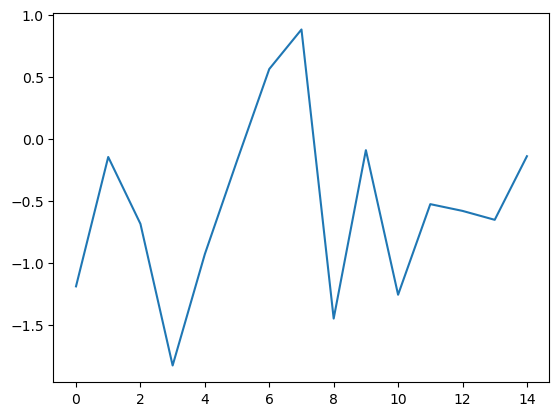

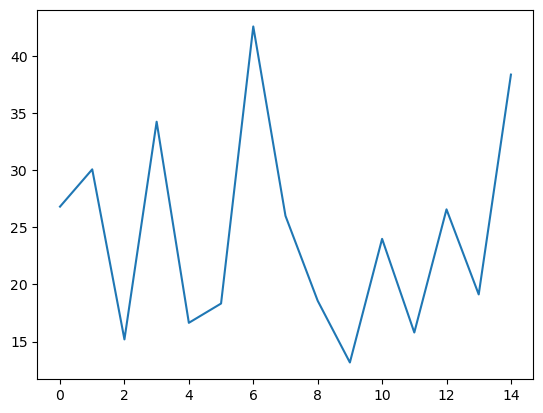

KeyboardInterrupt: 

In [25]:
if __name__ == '__main__':
    while(True):
        play_with_agent(agent)
#     play()

In [ ]:
# TO DO LIST #

# GHOST
# T spin collide